# Satellite Image Classification


In [1]:
!pip install -q torchsummary torchview

In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset

import torchvision
from torchvision import transforms, datasets, models

from torchsummary import summary
from torchview import draw_graph
from IPython.display import Image, display

from sklearn.metrics import f1_score, confusion_matrix

from collections import Counter, defaultdict
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")


reproducibility()

Random seed set to 42


## 0: Dataset and Preprocessing


In [5]:
base_transform = transforms.Compose([transforms.ToTensor()])

eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=base_transform)

100%|██████████| 94.3M/94.3M [00:02<00:00, 45.1MB/s]


In [6]:
num_images = len(eurosat_data)
class_names = eurosat_data.classes
num_classes = len(eurosat_data.classes)
img_shape = eurosat_data[0][0].shape

print(f"Total images: {num_images}")
print(f"Total classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Image shape: {img_shape}")

Total images: 27000
Total classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape: torch.Size([3, 64, 64])


In [7]:
train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(90),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [8]:
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(eurosat_data):
    class_indices[label].append(idx)

train_full_idx = []
train_10shot_idx = []
train_5shot_idx = []
val_idx = []
test_idx = []

for label, indices in class_indices.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices = indices[:n_train]
    val_indices = indices[n_train : n_train + n_val]
    test_indices = indices[n_train + n_val :]
    train_full_idx.extend(train_indices)
    val_idx.extend(val_indices)
    test_idx.extend(test_indices)
    train_10shot_idx.extend(train_indices[:10])
    train_5shot_idx.extend(train_indices[:5])

train_full = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_full_idx,
)
train_10shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_10shot_idx,
)
train_5shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_5shot_idx,
)
val_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    val_idx,
)
test_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    test_idx,
)

splits = {
    "Train full": train_full,
    "Train 10-shot": train_10shot,
    "Train 5-shot": train_5shot,
    "Validation": val_set,
    "Test": test_set,
}

for name, split in splits.items():
    labels = [label for _, label in split]
    counts = Counter(labels)
    print(f"\n{name}")
    print(f"Total samples: {len(split)}")
    for cls_id, cls_name in enumerate(class_names):
        print(f"    {cls_name}: {counts.get(cls_id, 0)}")


Train full
Total samples: 18900
    AnnualCrop: 2100
    Forest: 2100
    HerbaceousVegetation: 2100
    Highway: 1750
    Industrial: 1750
    Pasture: 1400
    PermanentCrop: 1750
    Residential: 2100
    River: 1750
    SeaLake: 2100

Train 10-shot
Total samples: 100
    AnnualCrop: 10
    Forest: 10
    HerbaceousVegetation: 10
    Highway: 10
    Industrial: 10
    Pasture: 10
    PermanentCrop: 10
    Residential: 10
    River: 10
    SeaLake: 10

Train 5-shot
Total samples: 50
    AnnualCrop: 5
    Forest: 5
    HerbaceousVegetation: 5
    Highway: 5
    Industrial: 5
    Pasture: 5
    PermanentCrop: 5
    Residential: 5
    River: 5
    SeaLake: 5

Validation
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 375
    Industrial: 375
    Pasture: 300
    PermanentCrop: 375
    Residential: 450
    River: 375
    SeaLake: 450

Test
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 

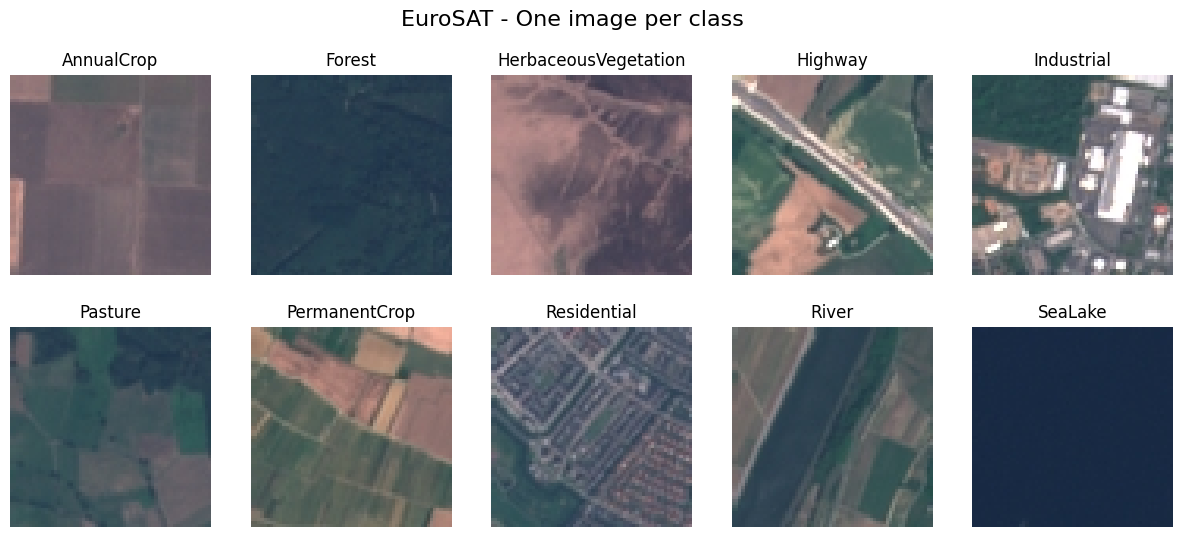

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls in range(num_classes):
    for img, label in eurosat_data:
        if label == cls:
            axes[cls].imshow(img.permute(1, 2, 0))
            axes[cls].set_title(class_names[cls])
            axes[cls].axis("off")
            break

plt.suptitle("EuroSAT - One image per class", fontsize=16)
plt.show()

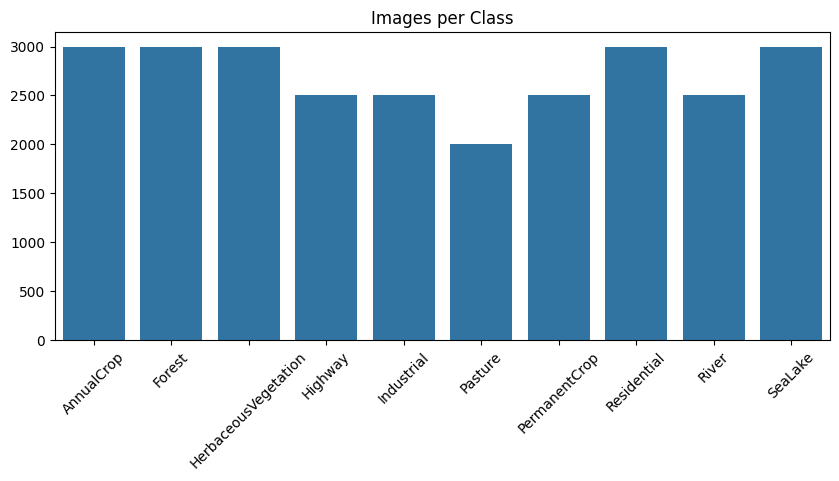

In [10]:
counts = [len(class_indices[c]) for c in range(num_classes)]
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

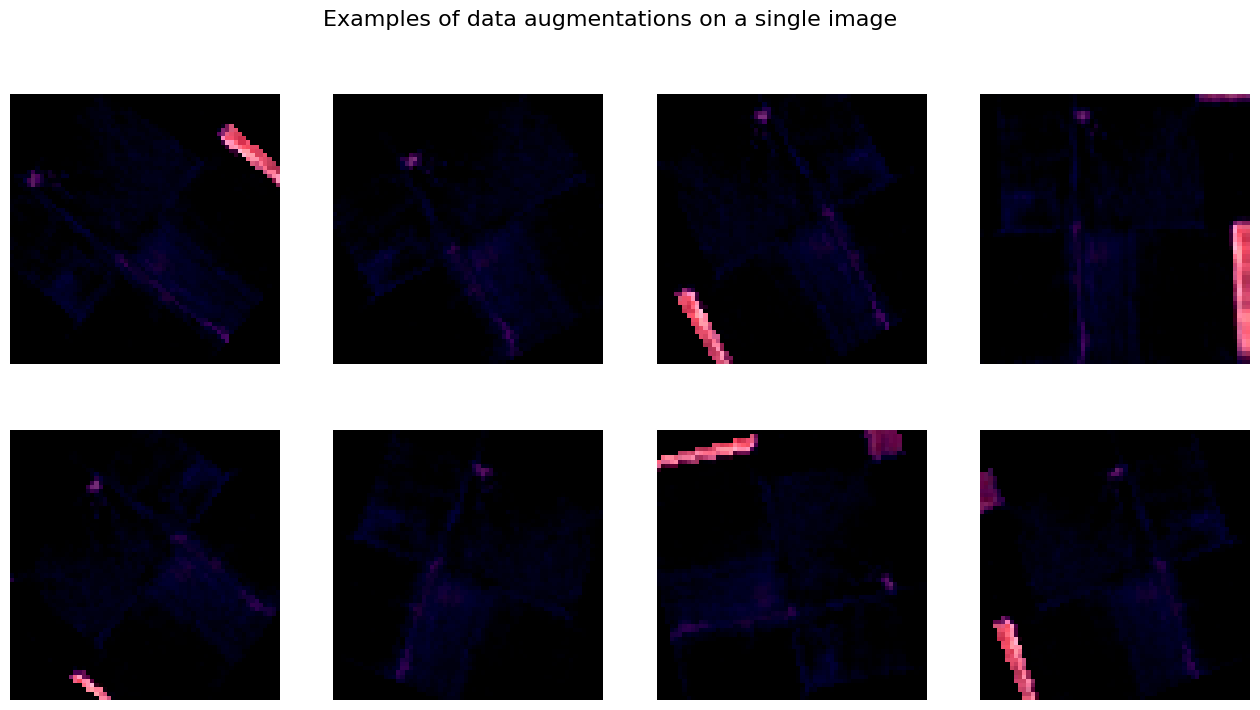

In [11]:
img, _ = eurosat_data[0]
pil_img = transforms.ToPILImage()(img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    aug_img = train_transform(pil_img)
    axes[i].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")

plt.suptitle("Examples of data augmentations on a single image", fontsize=16)
plt.show()

## 1: Baseline and Transfer Learning


### Task 1.1 - Baseline CNN from scratch


In [12]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes).to(device)
summary(model, input_size=(3, 64, 64), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
       BatchNorm2d-2           [-1, 32, 64, 64]              64
              ReLU-3           [-1, 32, 64, 64]               0
         MaxPool2d-4           [-1, 32, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          18,496
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]          73,856
      BatchNorm2d-10          [-1, 128, 16, 16]             256
             ReLU-11          [-1, 128, 16, 16]               0
        MaxPool2d-12            [-1, 128, 8, 8]               0
          Flatten-13                 [-1, 8192]               0
           Linear-14                  [

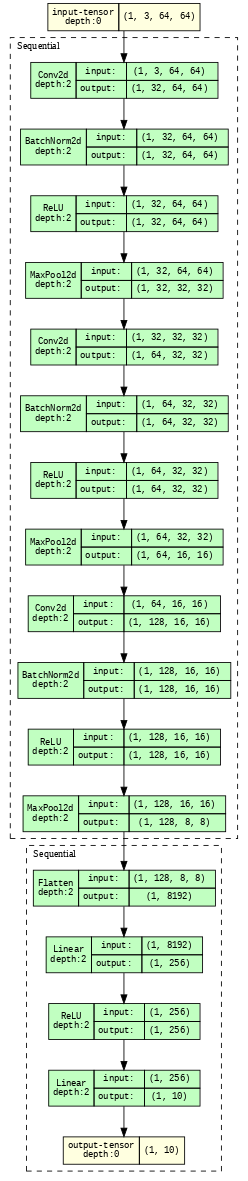

In [13]:
model_graph = draw_graph(
    model, input_size=(1, 3, 64, 64), expand_nested=True, device=device
)
model_graph.visual_graph.render("baseline_cnn", format="png")
display(Image("baseline_cnn.png"))

In [14]:
def train_per_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    acc = correct / total
    loss = total_loss / total
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return loss, acc, cm, f1


def train_model(
    model, train_loader, val_loader, test_loader, optimizer, criterion, num_epochs
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_per_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    training_time = time.time() - start_time
    test_loss, test_acc, test_cm, test_f1 = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_accuracy": test_acc,
        "test_f1": test_f1,
        "confusion_matrix": test_cm,
        "training_time": training_time,
    }

In [15]:
batch_size = 32

train_loader = DataLoader(
    train_full, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

In [16]:
reproducibility()
model = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0938, Train Acc: 0.6152 | Val Loss: 0.7915, Val Acc: 0.7109
Epoch 2/12 | Train Loss: 0.7667, Train Acc: 0.7286 | Val Loss: 0.6429, Val Acc: 0.7778
Epoch 3/12 | Train Loss: 0.6753, Train Acc: 0.7592 | Val Loss: 0.7392, Val Acc: 0.7827
Epoch 4/12 | Train Loss: 0.6175, Train Acc: 0.7842 | Val Loss: 0.6552, Val Acc: 0.7731
Epoch 5/12 | Train Loss: 0.5600, Train Acc: 0.8012 | Val Loss: 0.5865, Val Acc: 0.8052
Epoch 6/12 | Train Loss: 0.5177, Train Acc: 0.8166 | Val Loss: 0.4785, Val Acc: 0.8393
Epoch 7/12 | Train Loss: 0.4653, Train Acc: 0.8383 | Val Loss: 0.3880, Val Acc: 0.8716
Epoch 8/12 | Train Loss: 0.4444, Train Acc: 0.8426 | Val Loss: 0.4764, Val Acc: 0.8388
Epoch 9/12 | Train Loss: 0.4270, Train Acc: 0.8532 | Val Loss: 0.5481, Val Acc: 0.8170
Epoch 10/12 | Train Loss: 0.3974, Train Acc: 0.8609 | Val Loss: 0.4287, Val Acc: 0.8499
Epoch 11/12 | Train Loss: 0.3934, Train Acc: 0.8629 | Val Loss: 0.3918, Val Acc: 0.8573
Epoch 12/12 | Train

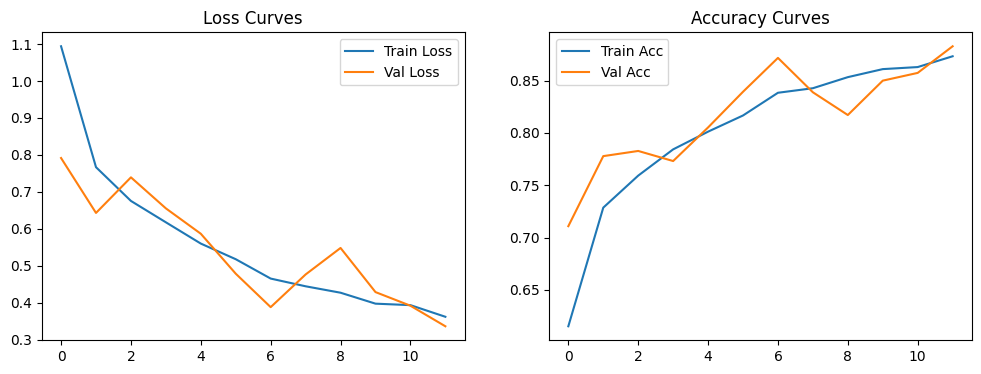

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results["train_losses"], label="Train Loss")
plt.plot(results["val_losses"], label="Val Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(results["train_accs"], label="Train Acc")
plt.plot(results["val_accs"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curves")

plt.show()

### Task 1.2 - Transfer Learning


In [ ]:
reproducibility()

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet18.parameters(), 1e-3)

results_resnet18 = train_model(
    model=resnet18,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=8,
)

Random seed set to 42
Epoch 1/8 | Train Loss: 0.6516, Train Acc: 0.7868 | Val Loss: 1.1532, Val Acc: 0.7160
Epoch 2/8 | Train Loss: 0.4157, Train Acc: 0.8654 | Val Loss: 0.2313, Val Acc: 0.9173
Epoch 3/8 | Train Loss: 0.3664, Train Acc: 0.8790 | Val Loss: 0.2852, Val Acc: 0.9047
Epoch 4/8 | Train Loss: 0.3134, Train Acc: 0.8950 | Val Loss: 0.3280, Val Acc: 0.8983
Epoch 5/8 | Train Loss: 0.2898, Train Acc: 0.9056 | Val Loss: 0.2641, Val Acc: 0.9111
Epoch 6/8 | Train Loss: 0.2740, Train Acc: 0.9105 | Val Loss: 0.1801, Val Acc: 0.9417
Epoch 7/8 | Train Loss: 0.2598, Train Acc: 0.9121 | Val Loss: 0.2283, Val Acc: 0.9232
Epoch 8/8 | Train Loss: 0.2467, Train Acc: 0.9158 | Val Loss: 0.1674, Val Acc: 0.9494
Test Accuracy: 93.28%
Training Time: 3.23 minutes


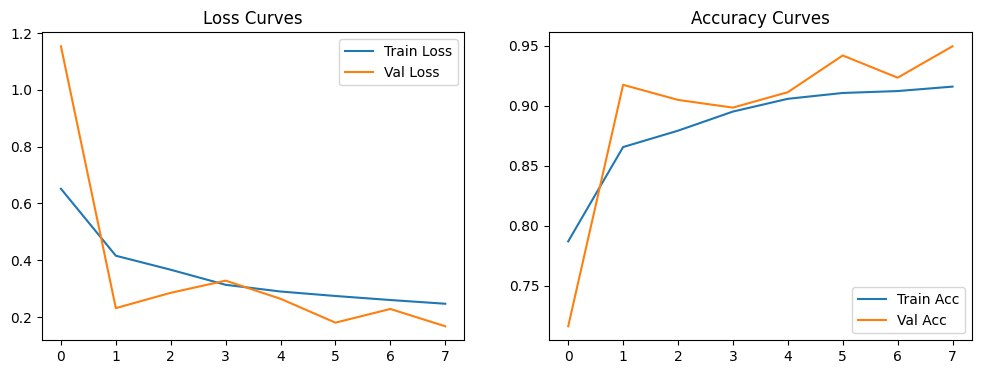

In [38]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results_resnet18["train_losses"], label="Train Loss")
plt.plot(results_resnet18["val_losses"], label="Val Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(results_resnet18["train_accs"], label="Train Acc")
plt.plot(results_resnet18["val_accs"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curves")

plt.show()

In [39]:
reproducibility()

resnet18_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet18_frozen.parameters():
    param.requires_grad = False
resnet18_frozen.fc = nn.Linear(resnet18_frozen.fc.in_features, num_classes)
resnet18_frozen = resnet18_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet18_frozen.parameters(), 1e-3)

results_resnet18_frozen = train_model(
    model=resnet18_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=8,
)

Random seed set to 42
Epoch 1/8 | Train Loss: 1.0526, Train Acc: 0.6551 | Val Loss: 0.9931, Val Acc: 0.6625
Epoch 2/8 | Train Loss: 0.8118, Train Acc: 0.7263 | Val Loss: 0.9815, Val Acc: 0.6195
Epoch 3/8 | Train Loss: 0.7988, Train Acc: 0.7300 | Val Loss: 0.9156, Val Acc: 0.6627
Epoch 4/8 | Train Loss: 0.7725, Train Acc: 0.7423 | Val Loss: 0.9200, Val Acc: 0.6481
Epoch 5/8 | Train Loss: 0.7669, Train Acc: 0.7396 | Val Loss: 0.9057, Val Acc: 0.6615
Epoch 6/8 | Train Loss: 0.7839, Train Acc: 0.7375 | Val Loss: 0.9756, Val Acc: 0.6506
Epoch 7/8 | Train Loss: 0.7712, Train Acc: 0.7413 | Val Loss: 0.8797, Val Acc: 0.6765
Epoch 8/8 | Train Loss: 0.7550, Train Acc: 0.7428 | Val Loss: 0.8628, Val Acc: 0.6948
Test Accuracy: 67.38%
Training Time: 2.74 minutes


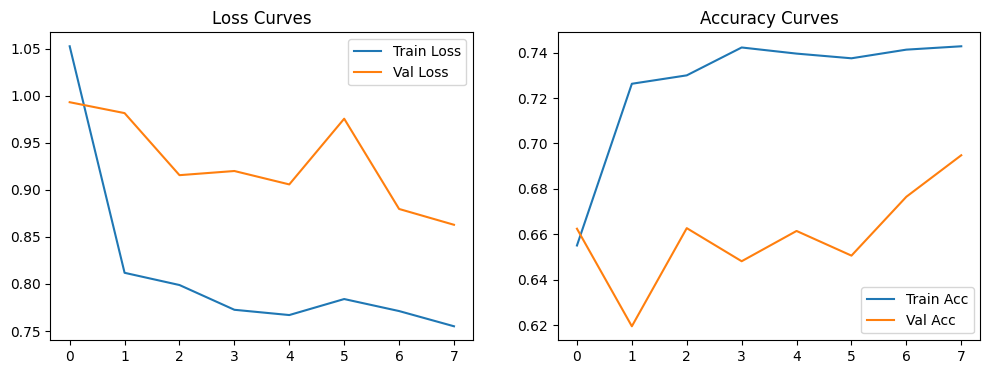

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results_resnet18_frozen["train_losses"], label="Train Loss")
plt.plot(results_resnet18_frozen["val_losses"], label="Val Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(results_resnet18_frozen["train_accs"], label="Train Acc")
plt.plot(results_resnet18_frozen["val_accs"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curves")

plt.show()